In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("play_tennis.csv")

df.head()

,day,outlook,temp,humidity,wind,play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes


In [3]:
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

df.head()

,day,outlook,temp,humidity,wind,play
0,0,2,1,0,1,0
1,6,2,1,0,0,0
2,7,0,1,0,1,1
3,8,1,2,0,1,1
4,9,1,0,1,1,1


In [6]:
X = df.drop("play", axis=1)
y = df["play"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [8]:
dt_under = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

dt_under.fit(X_train, y_train)

train_acc = accuracy_score(y_train, dt_under.predict(X_train))
test_acc = accuracy_score(y_test, dt_under.predict(X_test))

print("Train Accuracy :", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy : 0.7
Test Accuracy : 0.75


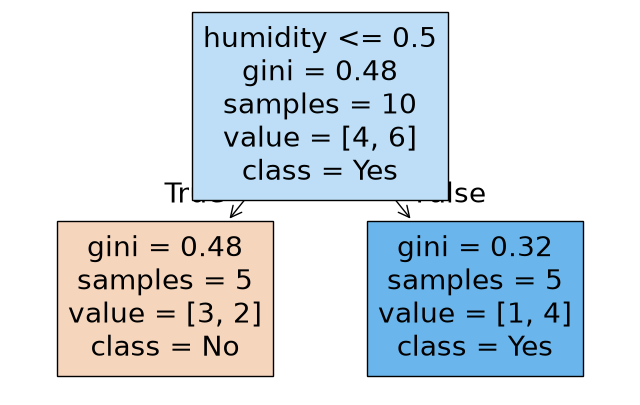

In [9]:
plt.figure(figsize=(8,5))

plot_tree(
    dt_under,
    feature_names=X.columns,
    class_names=["No","Yes"],
    filled=True
)

plt.show()

In [10]:
dt_best = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt_best.fit(X_train, y_train)

train_acc = accuracy_score(y_train, dt_best.predict(X_train))
test_acc = accuracy_score(y_test, dt_best.predict(X_test))

print("Train Accuracy :", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy : 1.0
Test Accuracy : 0.75


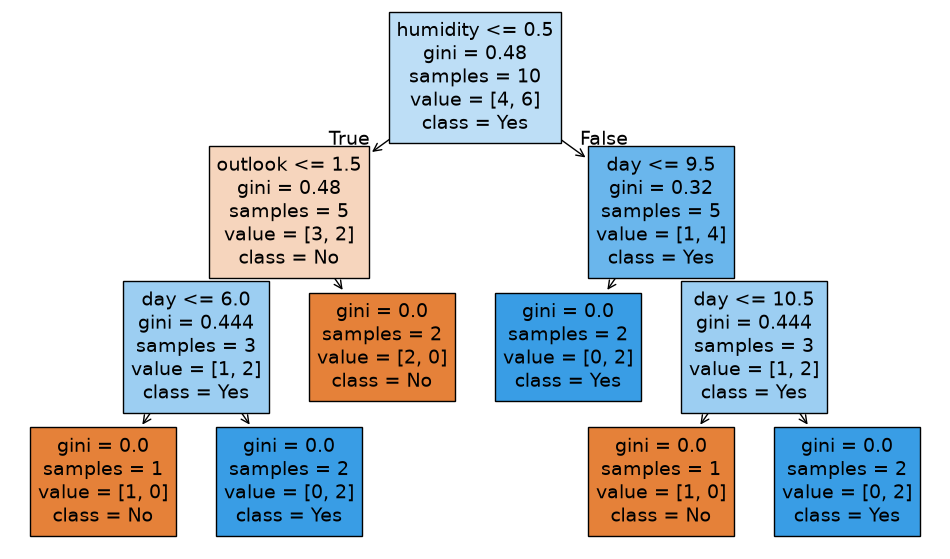

In [11]:
plt.figure(figsize=(12,7))

plot_tree(
    dt_best,
    feature_names=X.columns,
    class_names=["No","Yes"],
    filled=True
)

plt.show()

In [12]:
dt_over = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

dt_over.fit(X_train, y_train)

train_acc = accuracy_score(y_train, dt_over.predict(X_train))
test_acc = accuracy_score(y_test, dt_over.predict(X_test))

print("Train Accuracy :", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy : 1.0
Test Accuracy : 0.75


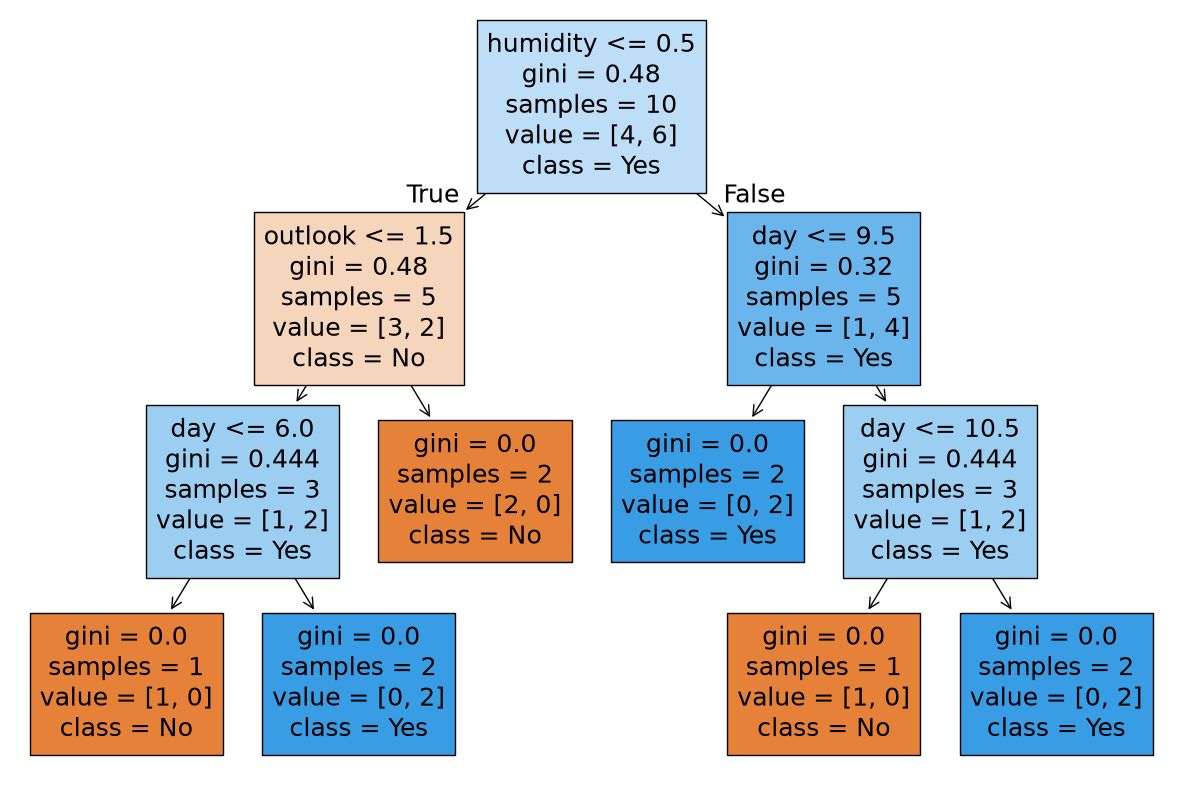

In [13]:
plt.figure(figsize=(15,10))

plot_tree(
    dt_over,
    feature_names=X.columns,
    class_names=["No","Yes"],
    filled=True
)

plt.show()

In [14]:
models = {
    "Underfitting": DecisionTreeClassifier(max_depth=1, random_state=42),
    "Good Model": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Overfitting": DecisionTreeClassifier(max_depth=None, random_state=42)
}

for name, model in models.items():

    model.fit(X_train, y_train)

    train = accuracy_score(y_train, model.predict(X_train))
    test = accuracy_score(y_test, model.predict(X_test))

    print(f"{name}")
    print("Train Accuracy :", round(train,3))
    print("Test Accuracy  :", round(test,3))
    print("-"*30)

Underfitting
Train Accuracy : 0.7
Test Accuracy  : 0.75
------------------------------
Good Model
Train Accuracy : 1.0
Test Accuracy  : 0.75
------------------------------
Overfitting
Train Accuracy : 1.0
Test Accuracy  : 0.75
------------------------------
